In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris

df = pd.read_csv('cluster_data_set.csv')
X = df.values

print(f"Shape: {X.shape}")
print(f"First 5 rows:\n{X[:5]}")

Shape: (3000, 2)
First 5 rows:
[[ 2.072345 -3.241693]
 [17.93671  15.78481 ]
 [ 1.083576  7.319176]
 [11.12067  14.40678 ]
 [23.71155   2.557729]]


In [3]:
def kmeans_scratch(X, k, max_iters=100, tol=1e-4, init='random', random_state=None):
    if random_state is not None:
        np.random.seed(random_state)
    
    n_samples, n_features = X.shape
    if init == 'random':
        random_indices = np.random.choice(n_samples, k, replace=False)
        centroids = X[random_indices].copy()
    
    elif init == 'kmeans++':
        centroids = np.zeros((k, n_features))
        centroids[0] = X[np.random.choice(n_samples)]
        for i in range(1, k):
            distances = np.min([np.linalg.norm(X - c, axis=1) for c in centroids[:i]], axis=0)
            probabilities = distances ** 2
            probabilities /= probabilities.sum()
            centroids[i] = X[np.random.choice(n_samples, p=probabilities)]
    for iteration in range(max_iters):
        distances = np.array([np.linalg.norm(X - c, axis=1) for c in centroids])
        labels = np.argmin(distances, axis=0)
        new_centroids = np.array([X[labels == i].mean(axis=0) for i in range(k)])
        shift = np.linalg.norm(new_centroids - centroids)
        centroids = new_centroids
        
        if shift < tol:
            print(f"Converged after {iteration + 1} iterations")
            break
    inertia = sum(np.linalg.norm(X[labels == i] - centroids[i])**2 for i in range(k))
    
    return labels, centroids, inertia

Converged after 3 iterations


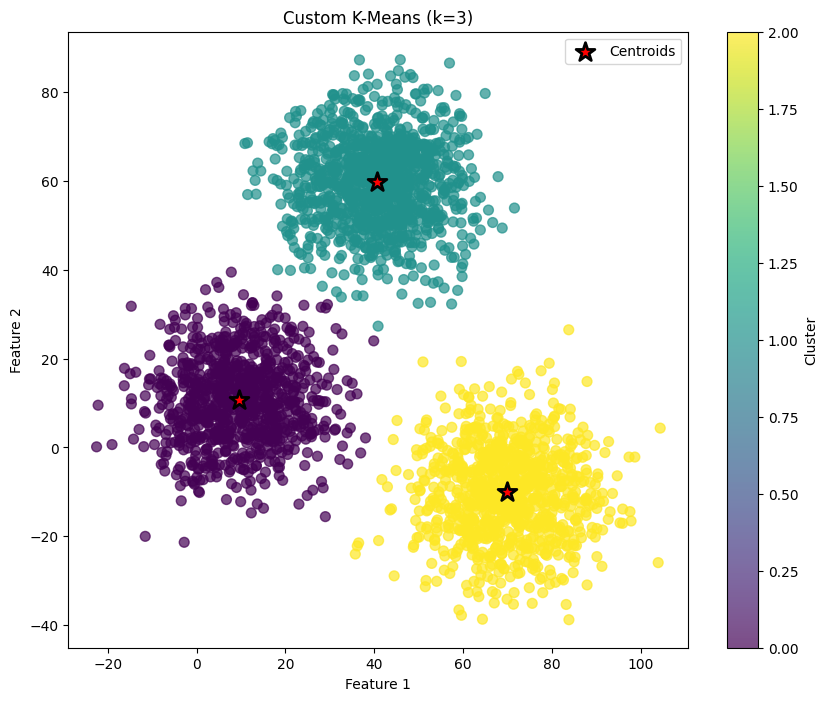

Custom K-Means Inertia: 611605.88


In [4]:
def plot_clusters(X, labels, centroids, title="K-Means Clustering Results"):
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50, alpha=0.7)
    plt.scatter(centroids[:, 0], centroids[:, 1], marker='*', s=200, 
                color='red', edgecolors='black', linewidth=2, label='Centroids')
    plt.colorbar(scatter, label='Cluster')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(title)
    plt.legend()
    plt.show()
labels_scratch, centroids_scratch, inertia_scratch = kmeans_scratch(
    X, k=3, max_iters=100, tol=1e-4, init='kmeans++', random_state=42
)

plot_clusters(X, labels_scratch, centroids_scratch, "Custom K-Means (k=3)")
print(f"Custom K-Means Inertia: {inertia_scratch:.2f}")

Converged after 3 iterations
Scikit-learn Inertia: 611605.88 (Time: 6.2818s)
Custom K-Means Inertia: 611605.88 (Time: 0.0020s)
Labels match: False


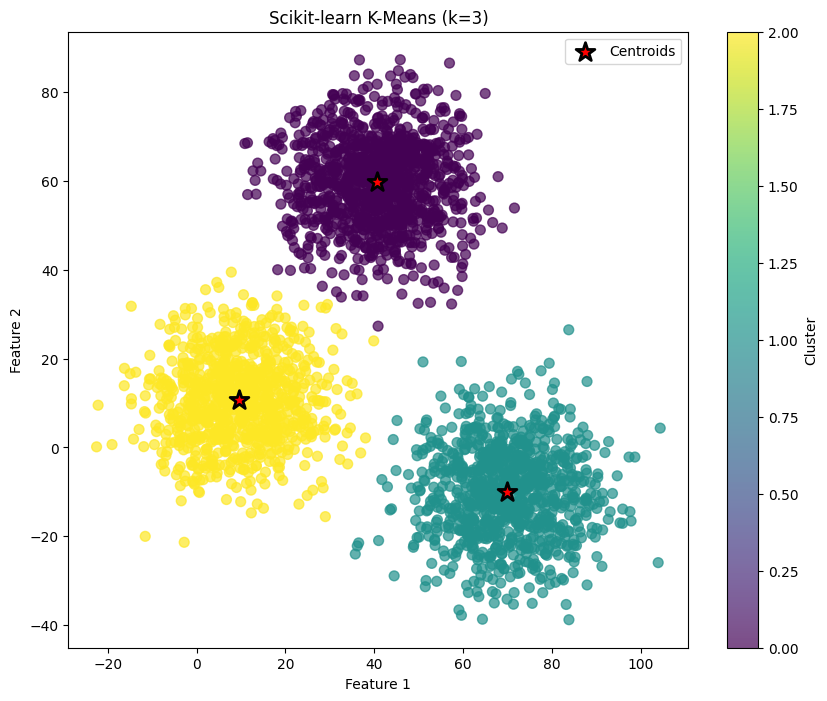

In [5]:
start_time = time.time()
kmeans_sklearn = KMeans(n_clusters=3, n_init=10, random_state=42)
labels_sklearn = kmeans_sklearn.fit_predict(X)
centroids_sklearn = kmeans_sklearn.cluster_centers_
inertia_sklearn = kmeans_sklearn.inertia_
sklearn_time = time.time() - start_time
start_time = time.time()
labels_custom, centroids_custom, inertia_custom = kmeans_scratch(
    X, k=3, max_iters=100, tol=1e-4, init='kmeans++', random_state=42
)
custom_time = time.time() - start_time
print(f"Scikit-learn Inertia: {inertia_sklearn:.2f} (Time: {sklearn_time:.4f}s)")
print(f"Custom K-Means Inertia: {inertia_custom:.2f} (Time: {custom_time:.4f}s)")
print(f"Labels match: {np.array_equal(labels_sklearn, labels_custom)}")
plot_clusters(X, labels_sklearn, centroids_sklearn, "Scikit-learn K-Means (k=3)")

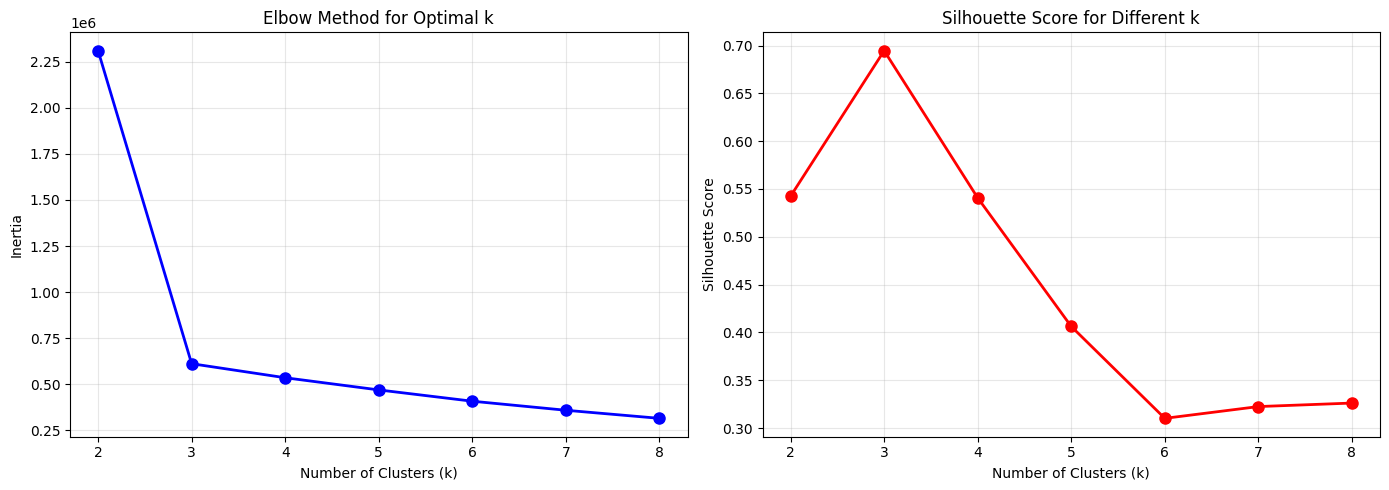

Optimal k (elbow method approx): 3
Optimal k (silhouette score): 3
Best silhouette score: 0.695 at k=3


In [14]:
k_values = range(2, 9)
inertias = []
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = kmeans.fit_predict(X)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, labels))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(k_values, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method for Optimal k')
ax1.grid(True, alpha=0.3)
ax2.plot(k_values, silhouette_scores, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score for Different k')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
best_k_elbow = k_values[np.argmin(np.diff(inertias, 2)) - 1]
best_k_silhouette = k_values[np.argmax(silhouette_scores)]
print(f"Optimal k (elbow method approx): {best_k_elbow}")
print(f"Optimal k (silhouette score): {best_k_silhouette}")
print(f"Best silhouette score: {max(silhouette_scores):.3f} at k={best_k_silhouette}")

In [15]:
iris = load_iris()
X_iris = iris.data
y_true = iris.target
feature_names = iris.feature_names
species_names = iris.target_names
scaler = StandardScaler()
X_iris_scaled = scaler.fit_transform(X_iris)

print(f"Iris data shape: {X_iris_scaled.shape}")
print(f"Feature names: {feature_names}")
print(f"Species: {species_names}")

Iris data shape: (150, 4)
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Species: ['setosa' 'versicolor' 'virginica']


In [16]:
kmeans_iris = KMeans(n_clusters=3, n_init=10, random_state=42)
labels_iris = kmeans_iris.fit_predict(X_iris_scaled)
comparison = pd.crosstab(
    pd.Series(y_true, name='True Species'), 
    pd.Series(labels_iris, name='Predicted Cluster')
)

print(comparison)
from scipy.stats import mode
mapping = {}
for i in range(3):
    mask = (labels_iris == i)
    true_labels_in_cluster = y_true[mask]
    if len(true_labels_in_cluster) > 0:
        majority_species = np.bincount(true_labels_in_cluster).argmax()
        mapping[i] = majority_species
labels_remapped = np.array([mapping[l] for l in labels_iris])
comparison_remapped = pd.crosstab(
    pd.Series(y_true, name='True Species'), 
    pd.Series(labels_remapped, name='Remapped Clusters')
) #compared series
# print(f"\ncomparison_remapped")
accuracy = np.mean(y_true == labels_remapped)
print(f"\nClustering Accuracy: {accuracy:.2%}")

Predicted Cluster   0   1   2
True Species                 
0                   0  50   0
1                  39   0  11
2                  14   0  36

Clustering Accuracy: 83.33%


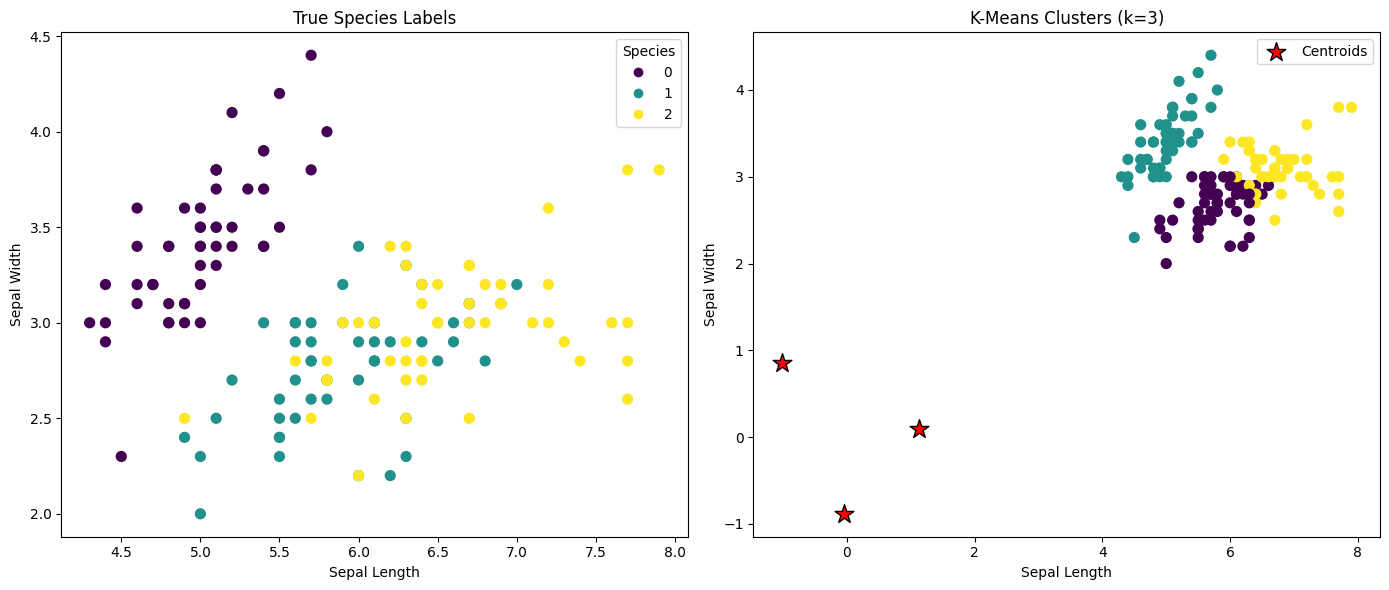

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
scatter1 = axes[0].scatter(X_iris[:, 0], X_iris[:, 1], c=y_true, cmap='viridis', s=50)
axes[0].set_xlabel('Sepal Length')
axes[0].set_ylabel('Sepal Width')
axes[0].set_title('True Species Labels')
axes[0].legend(*scatter1.legend_elements(), title='Species')
scatter2 = axes[1].scatter(X_iris[:, 0], X_iris[:, 1], c=labels_iris, cmap='viridis', s=50)
axes[1].scatter(kmeans_iris.cluster_centers_[:, 0], kmeans_iris.cluster_centers_[:, 1],
                marker='*', s=200, color='red', edgecolors='black', label='Centroids')
axes[1].set_xlabel('Sepal Length')
axes[1].set_ylabel('Sepal Width')
axes[1].set_title('K-Means Clusters (k=3)')
axes[1].legend()

plt.tight_layout()
plt.show()

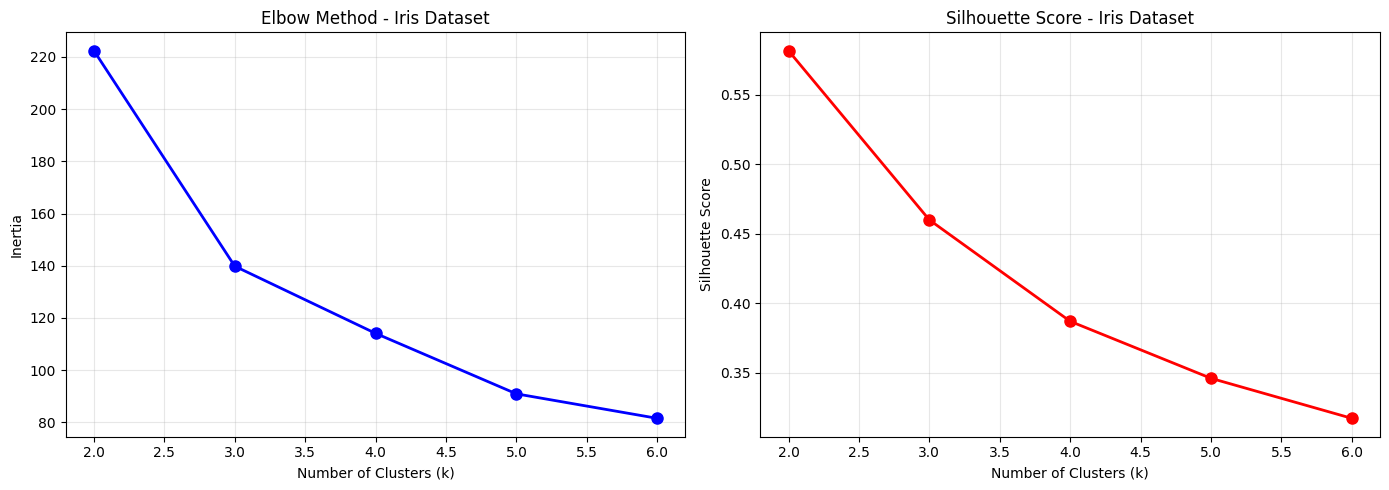

Best silhouette score for iris: 0.582 at k=2


In [18]:
k_values_iris = range(2, 7)
inertias_iris = []
silhouette_scores_iris = []

for k in k_values_iris:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = kmeans.fit_predict(X_iris_scaled)
    inertias_iris.append(kmeans.inertia_)
    silhouette_scores_iris.append(silhouette_score(X_iris_scaled, labels))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(k_values_iris, inertias_iris, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method - Iris Dataset')
ax1.grid(True, alpha=0.3)

ax2.plot(k_values_iris, silhouette_scores_iris, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score - Iris Dataset')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Best silhouette score for iris: {max(silhouette_scores_iris):.3f} at k={k_values_iris[np.argmax(silhouette_scores_iris)]}")